# Predicting Student Academic Risk Using Behavioural and Study Habit Data

## Project Objective

This project explores whether student behavioural, lifestyle, and study-related variables can be used to predict academic performance risk. The analysis includes exploratory data analysis, preprocessing of ordinal and categorical variables, model comparison and interpretation of the most important predictors.

## 1. Import Packages

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Feature importance
from sklearn.inspection import permutation_importance

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load and Inspect Data

In [2]:
# Load dataset
df = pd.read_excel("hybrid_student_performance_1200.xlsx")

# Preview first few rows
df.head()

,student_id,timestamp,year_class,program_stream,age,gender,cgpa_category,academic_satisfaction,study_hours_daily,daily_productivity,revision_frequency,focus_duration,screen_time_non_study,main_distractor,study_consistency,tasks_on_time,preparation_status,career_goal_clarity,skills_developing,energy_level,stress_level,routine_rating,sleepy_during_study,sleep_hours,career_interest,online_courses,projects_internships,programming_foundation,events_participation,assignments_on_time,attendance_percentage,strongest_asset,internal_barrier,external_resources,external_pressure,performance_risk_level
0,STU0001,3/29/2026 20:54:43,Second Year (SY),BCA,20,Female,8.5 – 9.4,Neutral,Less than 1 hour,2.0,Never,1–2 hours,More than 6 hours,Social media,Rarely,Sometimes,Planning to start soon,Somewhat clear,"Hard skills (programming, data analytics, tech...",4.0,4.0,1.0,Sometimes,6–7 hours,Other,"Not currently, but intend to in the future","Yes, actively working on projects/internship","Basic knowledge, learning while practicing",Occasionally participate in events,Often,Above 85%,"Technical/Hard Skills (Coding, Math, Logic)",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),No Impact (Fully supportive environment),Moderate Risk
1,STU0002,3/29/2026 21:20:15,Second Year (SY),BCA,20,Male,8.5 – 9.4,Unsatisfied,1–2 hours,1.0,Rarely,30–60 minutes,2–4 hours,Video content (YouTube/OTT),Sometimes,Sometimes,Planning to start soon,Somewhat clear,Both hard and soft skills,2.0,3.0,1.0,Often,6–7 hours,Automation Engineer,"Yes, currently enrolled in one or more courses...","Yes, actively working on projects/internship","Limited knowledge, theoretical only","Rarely participate, mostly observe",Often,76% – 85%,"Creative/Design Skills (Innovation, UI/UX, Con...",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),Moderate Impact (Occasional disruption),Moderate Risk
2,STU0003,3/29/2026 21:21:35,Second Year (SY),BCA,19,Male,5.0 – 6.9,Neutral,1–2 hours,2.0,Few times a week,1–2 hours,4–6 hours,Social interactions,Mostly consistent,Often,Actively preparing for a goal (placements/exams),Very clear,Both hard and soft skills,4.0,5.0,2.0,Often,6–7 hours,Cyber Security Analyst,Planning to enroll soon,"Yes, actively working on projects/internship","Basic knowledge, learning while practicing","Rarely participate, mostly observe",Often,Less than 50%,"Technical/Hard Skills (Coding, Math, Logic)",Difficulty with Focus / Concentration,Rarely (Passive),High Impact (Frequent disruption),High Risk
3,STU0004,3/29/2026 21:27:44,Second Year (SY),BCA,19,Female,8.5 – 9.4,Satisfied,1–2 hours,3.0,Rarely,1–2 hours,More than 6 hours,Social interactions,Sometimes,Often,Planning to start soon,Somewhat clear,Both hard and soft skills,3.0,2.0,2.0,Always,6–7 hours,Cyber Security Analyst,Planning to enroll soon,Planning to start a project/internship soon,"Basic knowledge, learning while practicing","Rarely participate, mostly observe",Often,Above 85%,"Management/Execution (Planning, Organizing, Di...",Procrastination / Low Motivation,Occasionally (When needed),High Impact (Frequent disruption),Low Risk
4,STU0005,3/29/2026 22:05:14,Second Year (SY),BCA,20,Female,8.5 – 9.4,NaN,1–2 hours,2.0,Rarely,1–2 hours,4–6 hours,Social media,Sometimes,Sometimes,Planning to start soon,Somewhat clear,Both hard and soft skills,3.0,5.0,2.0,Always,4–5 hours,Data Analyst,Planning to enroll soon,Planning to start a project/internship soon,"Basic knowledge, learning while practicing",Occasionally participate in events,Often,76% – 85%,"Management/Execution (Planning, Organizing, Di...",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),High Impact (Frequent disruption),High Risk


In [3]:
# Check dataset dimensions
df.shape

(1200, 36)

In [4]:
# Check column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              1200 non-null   object 
 1   timestamp               1200 non-null   object 
 2   year_class              1200 non-null   object 
 3   program_stream          1200 non-null   object 
 4   age                     1200 non-null   int64  
 5   gender                  1200 non-null   object 
 6   cgpa_category           1200 non-null   object 
 7   academic_satisfaction   1199 non-null   object 
 8   study_hours_daily       1200 non-null   object 
 9   daily_productivity      1166 non-null   float64
 10  revision_frequency      1166 non-null   object 
 11  focus_duration          1157 non-null   object 
 12  screen_time_non_study   1168 non-null   object 
 13  main_distractor         1200 non-null   object 
 14  study_consistency       1200 non-null   

In [5]:
# Summary statistics for numerical columns
df.describe()

,age,daily_productivity,energy_level,stress_level,routine_rating
count,1200.000000,1166.000000,1172.000000,1165.000000,1159.000000
mean,20.807500,2.686964,3.227816,3.151931,2.105263
std,2.186953,1.178761,1.145359,1.189194,0.788057
min,17.000000,1.000000,1.000000,1.000000,1.000000
25%,19.000000,2.000000,2.000000,2.000000,1.000000
50%,21.000000,3.000000,3.000000,3.000000,2.000000
75%,22.000000,3.000000,4.000000,4.000000,3.000000
max,26.000000,5.000000,5.000000,5.000000,3.000000


In [6]:
# Check target distribution
df["performance_risk_level"].value_counts()

performance_risk_level
Moderate Risk    572
High Risk        452
Low Risk         176
Name: count, dtype: int64

The response variable contains three risk categories: Low Risk, Moderate Risk, and High Risk. The distribution will be explored further in the EDA section.

In [7]:
# Check missing values
df.isna().sum().sort_values(ascending=False)

events_participation      58
sleep_hours               55
external_resources        45
focus_duration            43
routine_rating            41
programming_foundation    41
online_courses            36
stress_level              35
revision_frequency        34
daily_productivity        34
screen_time_non_study     32
external_pressure         29
energy_level              28
academic_satisfaction      1
timestamp                  0
student_id                 0
program_stream             0
year_class                 0
cgpa_category              0
gender                     0
skills_developing          0
career_goal_clarity        0
preparation_status         0
tasks_on_time              0
main_distractor            0
study_consistency          0
age                        0
study_hours_daily          0
projects_internships       0
career_interest            0
sleepy_during_study        0
assignments_on_time        0
strongest_asset            0
attendance_percentage      0
internal_barri

In [8]:
# Check how many rows would remain after dropping missing values
rows_before = df.shape[0]
rows_after = df.dropna().shape[0]

print(f"Rows before dropping missing values: {rows_before}")
print(f"Rows after dropping missing values: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")
print(f"Percentage retained: {rows_after / rows_before:.2%}") 

Rows before dropping missing values: 1200
Rows after dropping missing values: 772
Rows removed: 428
Percentage retained: 64.33%


Complete-case removal would reduce the dataset from 1,200 observations to 773 observations, meaning 427 rows would be removed and only 64.42% of the original data would remain. This is a substantial loss of data, especially because the target variable contains a smaller Low Risk class.

For this reason, rows with missing values will not be dropped. Instead, missing values will be handled during preprocessing. Numerical variables will be imputed using the median, while categorical variables will be imputed using the most frequent category. These imputation steps will be included inside the modelling pipeline to avoid data leakage from the test set.

## 3. Data Cleaning and Feature Preparation

The dataset contains a large number of categorical variables. Some variables are nominal, meaning the categories do not have a natural order, such as gender, program stream, and main distractor. These variables will be one-hot encoded during preprocessing.

Several remaining categorical variables are ordinal, meaning the categories have a meaningful order. Examples include study hours, focus duration, screen time, task completion, preparation status, and career goal clarity. These variables will be ordinal encoded so that their ordering is preserved without creating unnecessary additional columns.

Missing values will also be handled during preprocessing rather than by dropping rows, since complete-case removal would retain only 64.42% of the original dataset.

### 3.1 Columns removed from analysis

The `student_id` column is a unique identifier for each student and does not contain predictive information about academic risk. The `timestamp` column records when the survey response was submitted, but this project focuses on student behaviours, study habits, lifestyle factors, and academic-related variables rather than time-based response patterns. Therefore, both columns were removed before modelling.

The dataset documentation states that the response variable, `performance_risk_level`, is derived from a weighted composite of `cgpa_category`, `attendance_percentage`, `stress_level`, and academic consistency. Since these variables directly contribute to the construction of the target label, including them as predictors would introduce target leakage and allow the model to partly reconstruct the target rather than learn from independent explanatory variables.

In the dataset, the closest directly available measure of academic consistency is `study_consistency`, so this variable was also removed from the main modelling dataset. However, “academic consistency” is not fully defined in the documentation and may also be conceptually related to other study behaviour variables, such as study hours, revision frequency, tasks completed on time, and assignments submitted on time. These variables were retained because they are not explicitly identified as target-construction variables, but their relationship with the derived target should be interpreted cautiously.

For this reason, `cgpa_category`, `attendance_percentage`, `stress_level`, and `study_consistency` are excluded from the main modelling dataset. This allows the main model to test whether academic risk can be predicted using the remaining behavioural, lifestyle, preparation, and background variables rather than simply reconstructing the target formula.

A secondary model including the direct target-construction variables may be tested later as a comparison. This would help show how much predictive performance increases when direct target-derived information is included, but the main model will remain the more realistic and methodologically defensible version.

In [9]:
# Define target variable
target = "performance_risk_level"

# Drop identifier, timestamp, and target-construction/leakage columns
drop_cols = [
    "student_id",
    "timestamp",
    "cgpa_category",
    "attendance_percentage",
    "stress_level",
    "study_consistency"
]

# Create cleaned dataframe for analysis and modelling
df_model = df.drop(columns=drop_cols)

# Create feature matrix and target vector
X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Cleaned dataframe shape: {df_model.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Cleaned dataframe shape: (1200, 30)
Feature matrix shape: (1200, 29)
Target vector shape: (1200,)


The cleaned dataframe `df_model` removes the identifier and timestamp columns, as well as variables that may introduce target leakage. The dataset documentation states that `performance_risk_level` is derived from a weighted composite of `cgpa_category`, `attendance_percentage`, `stress_level`, and academic consistency. Therefore, `cgpa_category`, `attendance_percentage`, `stress_level`, and `study_consistency` are excluded from the main modelling dataset so that the model is not simply learning the variables used to construct the target label.

This dataframe will be used for the remaining exploratory data analysis and modelling so that the analysis is aligned with the final modelling question: whether academic risk can be predicted using the remaining behavioural, lifestyle, preparation, and background variables. The feature matrix `X` contains the predictor variables, while `y` contains the response variable, `performance_risk_level`.

### 3.2 Feature groups for preprocessing

The remaining predictors are separated into numerical, ordinal categorical, and nominal categorical variables. These groups will be used later to apply the appropriate preprocessing steps inside the modelling pipeline.

In [10]:
# Numerical features
numeric_features = [
    "age",
    "daily_productivity",
    "energy_level",
    "routine_rating"
]

# Ordinal categorical features
ordinal_features = [
    "year_class",
    "academic_satisfaction",
    "study_hours_daily",
    "revision_frequency",
    "focus_duration",
    "screen_time_non_study",
    "tasks_on_time",
    "preparation_status",
    "career_goal_clarity",
    "sleepy_during_study",
    "sleep_hours",
    "online_courses",
    "projects_internships",
    "programming_foundation",
    "events_participation",
    "assignments_on_time",
    "external_resources",
    "external_pressure"
]

# Nominal categorical features
nominal_features = [
    "program_stream",
    "gender",
    "main_distractor",
    "skills_developing",
    "career_interest",
    "strongest_asset",
    "internal_barrier"
]

In [11]:
# Display unique values for ordinal categorical features
for col in ordinal_features:
    print(f"\n{col}")
    print(X[col].dropna().unique())


year_class
['Second Year (SY)' 'First Year (FY)' 'Third Year (TY)' 'Final Year'
 'First Year (PG)' 'Second Year (PG)']

academic_satisfaction
['Neutral' 'Unsatisfied' 'Satisfied' 'Very satisfied' 'Very unsatisfied']

study_hours_daily
['Less than 1 hour' '1–2 hours' 'More than 2 hours']

revision_frequency
['Never' 'Rarely' 'Few times a week' 'Daily']

focus_duration
['1–2 hours' '30–60 minutes' 'More than 2 hours']

screen_time_non_study
['More than 6 hours' '2–4 hours' '4–6 hours']

tasks_on_time
['Sometimes' 'Often' 'Always' 'Rarely']

preparation_status
['Planning to start soon'
 'Actively preparing for a goal (placements/exams)' 'Thinking about it']

career_goal_clarity
['Somewhat clear' 'Very clear' 'Not clear']

sleepy_during_study
['Sometimes' 'Often' 'Always' 'Never']

sleep_hours
['6–7 hours' '4–5 hours' 'More than 8 hours']

online_courses
['Not currently, but intend to in the future'
 'Yes, currently enrolled in one or more courses/certifications'
 'Planning to enroll soon

In [12]:
# Define ordinal mappings
ordinal_mappings = {
    "year_class": {
        "First Year (FY)": 1,
        "Second Year (SY)": 2,
        "Third Year (TY)": 3,
        "Final Year": 4,
        "First Year (PG)": 5,
        "Second Year (PG)": 6
    },
    
    "academic_satisfaction": {
        "Very unsatisfied": 1,
        "Unsatisfied": 2,
        "Neutral": 3,
        "Satisfied": 4,
        "Very satisfied": 5
    },

    "study_hours_daily": {
        "Less than 1 hour": 1,
        "1–2 hours": 2,
        "More than 2 hours": 3
    },

    "revision_frequency": {
        "Never": 1,
        "Rarely": 2,
        "Few times a week": 3,
        "Daily": 4
    },

    "focus_duration": {
        "30–60 minutes": 1,
        "1–2 hours": 2,
        "More than 2 hours": 3
    },

    "screen_time_non_study": {
        "2–4 hours": 1,
        "4–6 hours": 2,
        "More than 6 hours": 3
    },

    "tasks_on_time": {
        "Rarely": 1,
        "Sometimes": 2,
        "Often": 3,
        "Always": 4
    },

    "preparation_status": {
        "Thinking about it": 1,
        "Planning to start soon": 2,
        "Actively preparing for a goal (placements/exams)": 3
    },

    "career_goal_clarity": {
        "Not clear": 1,
        "Somewhat clear": 2,
        "Very clear": 3
    },

    "sleepy_during_study": {
        "Never": 1,
        "Sometimes": 2,
        "Often": 3,
        "Always": 4
    },

    "sleep_hours": {
        "4–5 hours": 1,
        "6–7 hours": 2,
        "More than 8 hours": 3
    },

    "online_courses": {
        "No, not interested": 1,
        "Not currently, but intend to in the future": 2,
        "Planning to enroll soon": 3,
        "Yes, currently enrolled in one or more courses/certifications": 4
    },

    "projects_internships": {
        "Not currently, but intend to in the future": 1,
        "Planning to start a project/internship soon": 2,
        "Yes, actively working on projects/internship": 3
    },

    "programming_foundation": {
        "Limited knowledge, theoretical only": 1,
        "Basic knowledge, learning while practicing": 2,
        "Strong foundation in core concepts": 3
    },

    "events_participation": {
        "Never participate in such events": 1,
        "Rarely participate, mostly observe": 2,
        "Occasionally participate in events": 3
    },

    "assignments_on_time": {
        "Rarely": 1,
        "Sometimes": 2,
        "Often": 3,
        "Always": 4
    },

    "external_resources": {
        "Never (Unaware or Not interested)": 1,
        "Rarely (Passive)": 2,
        "Occasionally (When needed)": 3
    },

    "external_pressure": {
        "No Impact (Fully supportive environment)": 1,
        "Low Impact (Rarely affects study)": 2,
        "Moderate Impact (Occasional disruption)": 3,
        "High Impact (Frequent disruption)": 4
    }
}

The feature groups and ordinal mappings have been defined at this stage, but the transformations will not be applied directly to the dataset yet. Encoding and imputation will be performed later inside the modelling pipeline so that preprocessing is fitted only on the training data and does not introduce data leakage.

## 4. Exploratory Data Analysis

The EDA focuses on understanding the distribution of the target variable and exploring how key study behaviour, lifestyle, and pressure-related variables differ across academic risk levels. The original categorical labels are used for readability, while ordinal category orderings are preserved in tables and plots where applicable.

For categorical predictors, row-normalised proportions are used instead of raw counts. This allows the distribution of risk levels to be compared within each response group and reduces the visual effect of the overall class imbalance in the target variable.

In [13]:
# Consistent colour palette for risk levels
risk_order = ["Low Risk", "Moderate Risk", "High Risk"]

risk_palette = {
    "Low Risk": "#4C5F8F",       # muted blue
    "Moderate Risk": "#2F837F",  # deep teal
    "High Risk": "#73B96F"       # soft green
}

# Use ordinal mappings to preserve logical category order in EDA tables and plots
category_orders = {
    col: list(mapping.keys())
    for col, mapping in ordinal_mappings.items()
}


In [14]:
# Define function to help with interpretability
def wrap_labels(ax, width=18, fontsize=9):
    labels = [
        textwrap.fill(label.get_text(), width=width)
        for label in ax.get_xticklabels()
    ]
    ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=fontsize)


# Define function to plot risk proportions as grouped bars
def plot_risk_proportions(
    data, feature, target, risk_order, risk_palette,
    category_orders=None, ax=None
):
    prop_table = (
        pd.crosstab(data[feature], data[target], normalize="index")
        .reindex(columns=risk_order)
    )

    if category_orders is not None and feature in category_orders:
        prop_table = prop_table.reindex(category_orders[feature])

    prop_table.plot(
        kind="bar",
        stacked=False,
        ax=ax,
        color=[risk_palette[risk] for risk in risk_order],
        legend=False
    )

    ax.set_title(f"{feature.replace('_', ' ').title()}", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")

    # Custom label handling for long category names
    if feature in ["career_interest"]:
        wrap_labels(ax, width=10, fontsize=7)
    elif feature in ["strongest_asset", "online_courses", "internal_barrier"]:
        wrap_labels(ax, width=12, fontsize=7)
    else:
        wrap_labels(ax, width=18, fontsize=8)


# Define function to plot subplots
def plot_feature_group(
    data, features, target, risk_order, risk_palette,
    category_orders=None, rows=2, cols=3, title=None
):
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.8 * rows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        plot_risk_proportions(
            data=data,
            feature=feature,
            target=target,
            risk_order=risk_order,
            risk_palette=risk_palette,
            category_orders=category_orders,
            ax=axes[i]
        )

    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Risk Level",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98)
    )

    if title:
        fig.suptitle(title, fontsize=16, y=0.995)

    plt.tight_layout(rect=[0, 0, 0.93, 0.96])
    fig.subplots_adjust(hspace=0.55, wspace=0.25)
    plt.show()


### 4.1 Target Variable Distribution

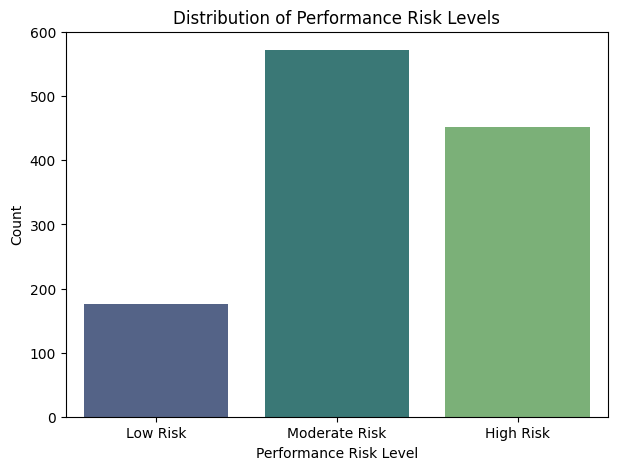

performance_risk_level
Moderate Risk    572
High Risk        452
Low Risk         176
Name: count, dtype: int64

In [15]:
# Target variable distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_model,
    x=target,
    order=risk_order,
    hue=target,
    palette=risk_palette,
    legend=False
)

plt.title("Distribution of Performance Risk Levels")
plt.xlabel("Performance Risk Level")
plt.ylabel("Count")
plt.show()

df_model[target].value_counts()

The response variable `performance_risk_level` has three categories: Moderate Risk, High Risk, and Low Risk. Moderate Risk is the most common class, followed by High Risk, while Low Risk has noticeably fewer observations.

Because the classes are not perfectly balanced, accuracy alone may not be sufficient for model evaluation. Later model performance will also be assessed using macro F1-score and the confusion matrix to check whether the model performs reasonably across all risk categories.

### 4.2 Study Behaviour Variables
This section explores study-related behaviours that may be associated with academic risk. Since the target-construction variables were removed from the main modelling dataset, the focus is on remaining variables such as study hours, revision frequency, focus duration, task completion, and assignment completion.

In [16]:
# Study behaviour variables to explore
study_behaviour_features = [
    "study_hours_daily",
    "revision_frequency",
    "focus_duration",
    "tasks_on_time",
    "assignments_on_time",
    "academic_satisfaction"
]

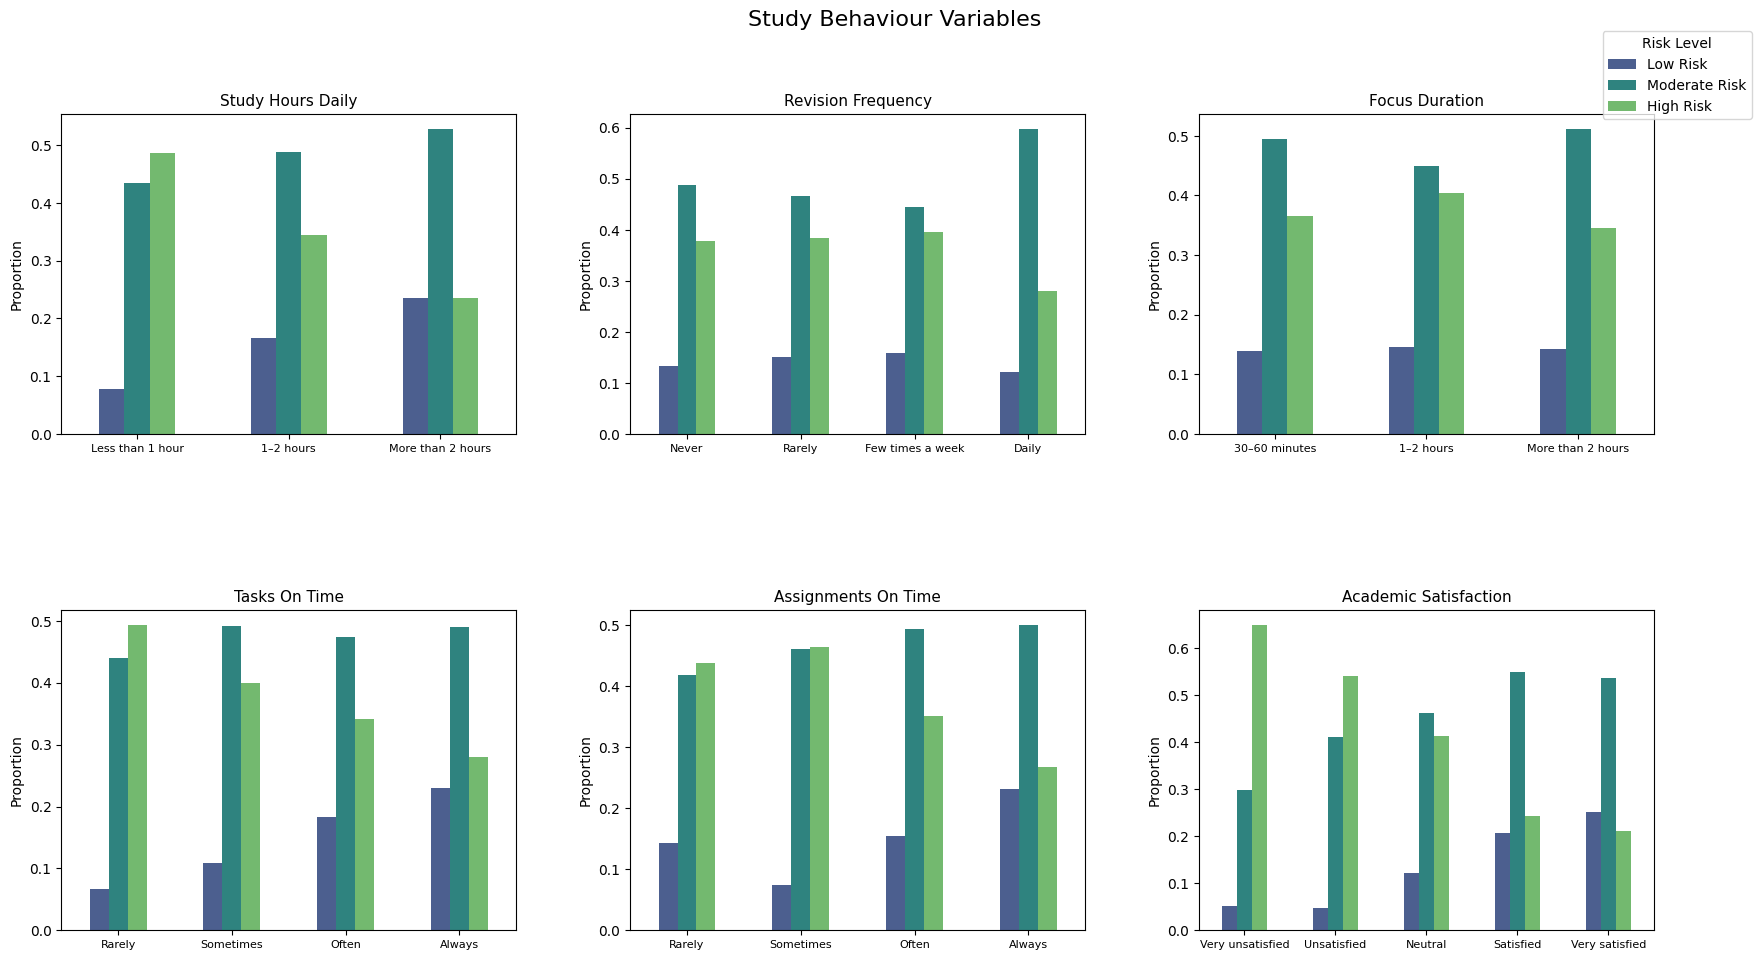

In [17]:
# Plot study behaviour variables against risk level
plot_feature_group(
    data=df_model,
    features=study_behaviour_features,
    target=target,
    risk_order=risk_order,
    risk_palette=risk_palette,
    category_orders=category_orders,
    rows=2,
    cols=3,
    title="Study Behaviour Variables"
)

#### 4.2.1 Study Behaviour Insights

The study behaviour variables suggest that consistency and engagement are generally associated with lower academic risk. Daily study hours, completing tasks on time, and academic satisfaction showed the clearest relationships, with higher levels of these behaviours generally corresponding to lower proportions of high-risk students.

Revision frequency showed a slightly less direct pattern, where daily revision had the lowest high-risk proportion but not the highest low-risk proportion. Focus duration appeared to have weaker separation between risk groups, suggesting it may be less useful as an individual predictor. Assignment punctuality also showed a less consistent pattern, with the “Rarely” category having a slightly higher low-risk proportion than “Sometimes”, although the overall trend still suggests lower high-risk proportions as assignment completion improves.

Overall, these plots suggest that study behaviour variables may provide useful predictive information, particularly variables related to consistency, satisfaction, and task completion. A recurring pattern is that reductions in high-risk proportions often correspond more clearly with increases in moderate-risk proportions rather than large increases in low-risk proportions, suggesting that positive study behaviours may reduce severe academic risk without necessarily guaranteeing low academic risk.

### 4.3 Lifestyle and Personal Behaviour Variables
This section explores lifestyle and personal behaviour variables that may be associated with academic risk. Since the target-construction variables were removed from the main modelling dataset, the focus is on remaining non-academic factors such as sleep patterns, sleepiness during study, non-study screen time, energy level, external pressure, external resource use, main distractors, and internal barriers.

In [18]:
# Lifestyle and personal behaviour variables to explore
lifestyle_features = [
    "sleep_hours",
    "sleepy_during_study",
    "screen_time_non_study",
    "energy_level",
    "external_pressure",
    "external_resources",
    "main_distractor",
    "internal_barrier"
]

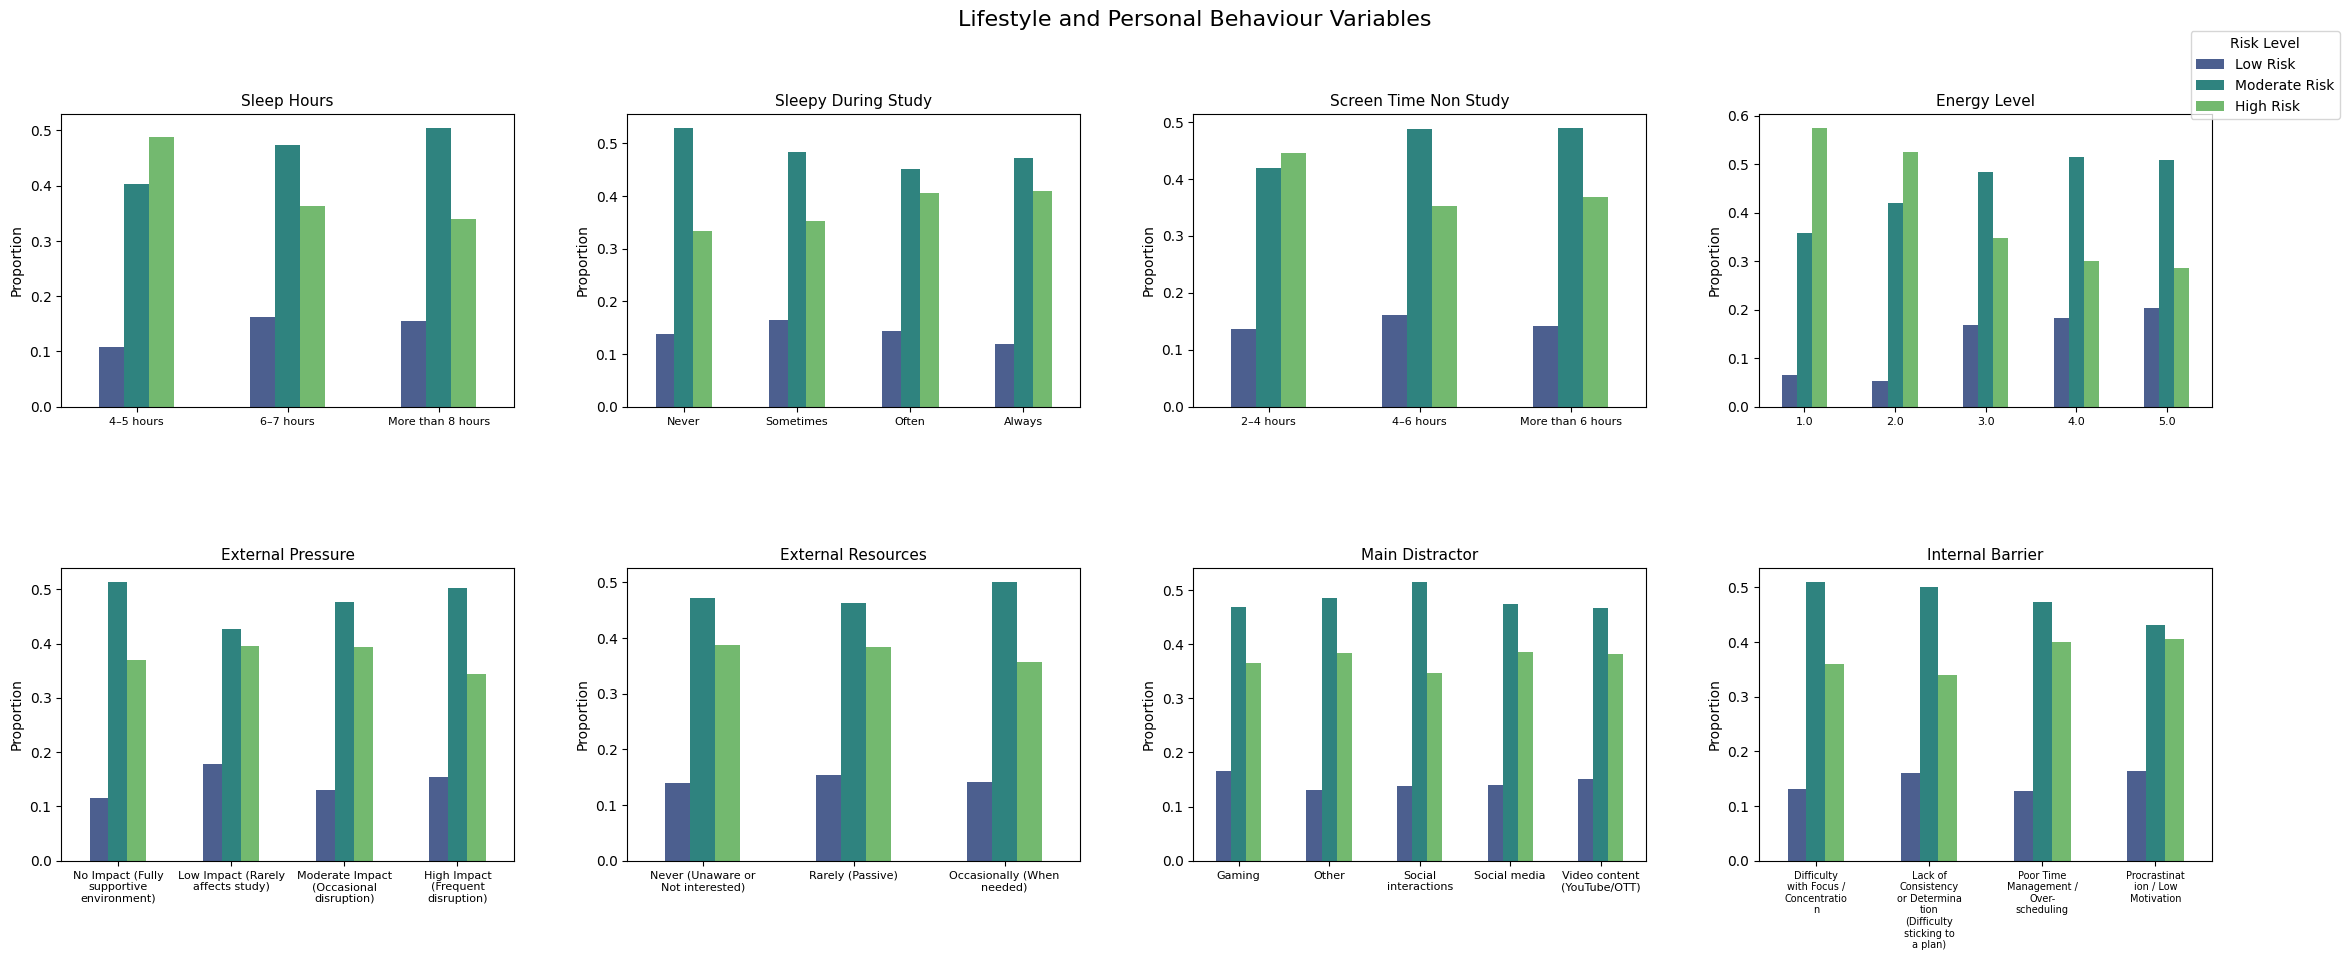

In [19]:
# Plot lifestyle and personal behaviour variables
plot_feature_group(
    data=df_model, 
    features=lifestyle_features, 
    target=target,
    risk_order=risk_order,
    risk_palette=risk_palette,
    category_orders=category_orders,
    rows=2,
    cols=4,
    title="Lifestyle and Personal Behaviour Variables")

### 4.3.1 Lifestyle and Personal Behaviour Insights

The lifestyle variables show mixed relationships with academic risk. Sleep hours and energy level appear to show the clearest patterns. Higher sleep hours are associated with a lower proportion of high-risk students, although the low-risk proportion peaks at 6–7 hours rather than more than 8 hours. Energy level shows a stronger and more consistent relationship, with low-risk proportions increasing and high-risk proportions decreasing as reported energy level increases.

Sleepiness during study shows a less direct pattern. Students who are always sleepy during study have the highest high-risk proportion, while moderate-risk proportions generally remain high across the categories. This suggests that sleepiness during study may still be relevant, but the relationship is not as clean as energy level.

Screen time outside of study does not show a strong or consistent relationship with academic risk. The low-risk proportion changes only slightly across categories, while moderate-risk increases and high-risk decreases somewhat as screen time increases. This pattern is somewhat counterintuitive and may suggest that screen time alone is not a strong explanatory variable without considering other behaviours.

External pressure also shows an uneven pattern. Low-risk proportions peak when pressure has a low impact rather than no impact, while high-risk proportions are lower at higher pressure-impact categories than expected. This may indicate that some level of external pressure is not necessarily harmful and could reflect motivation or accountability, depending on the student.

External resources show relatively small differences between risk groups, suggesting this variable may have weaker individual predictive value. Similarly, main distractor does not display a clear ordinal trend, which is expected since the categories are nominal rather than ordered.

Internal barriers are also difficult to interpret as a trend because the categories are not ordinal. However, procrastination/low motivation has both a relatively high low-risk and high-risk proportion compared with other categories, suggesting that this barrier may affect students differently depending on other factors.

Overall, lifestyle variables appear to provide useful information, but the strongest individual indicators seem to be energy level and sleep hours. Several lifestyle variables show weaker or less direct patterns, meaning they may be more useful in combination with study behaviour variables rather than as standalone predictors.

### 4.4 Preparation and Career Development Variables

This section explores preparation and career development variables that may be associated with academic risk. These variables capture goal clarity, career preparation, online course engagement, project or internship involvement, programming foundation, event participation, skill development focus, career interests, and perceived strengths.

In [20]:
# Preparation and career development variables to explore
preparation_features = [
    "career_goal_clarity",
    "preparation_status",
    "online_courses",
    "projects_internships",
    "programming_foundation",
    "events_participation",
    "skills_developing",
    "career_interest",
    "strongest_asset"
]


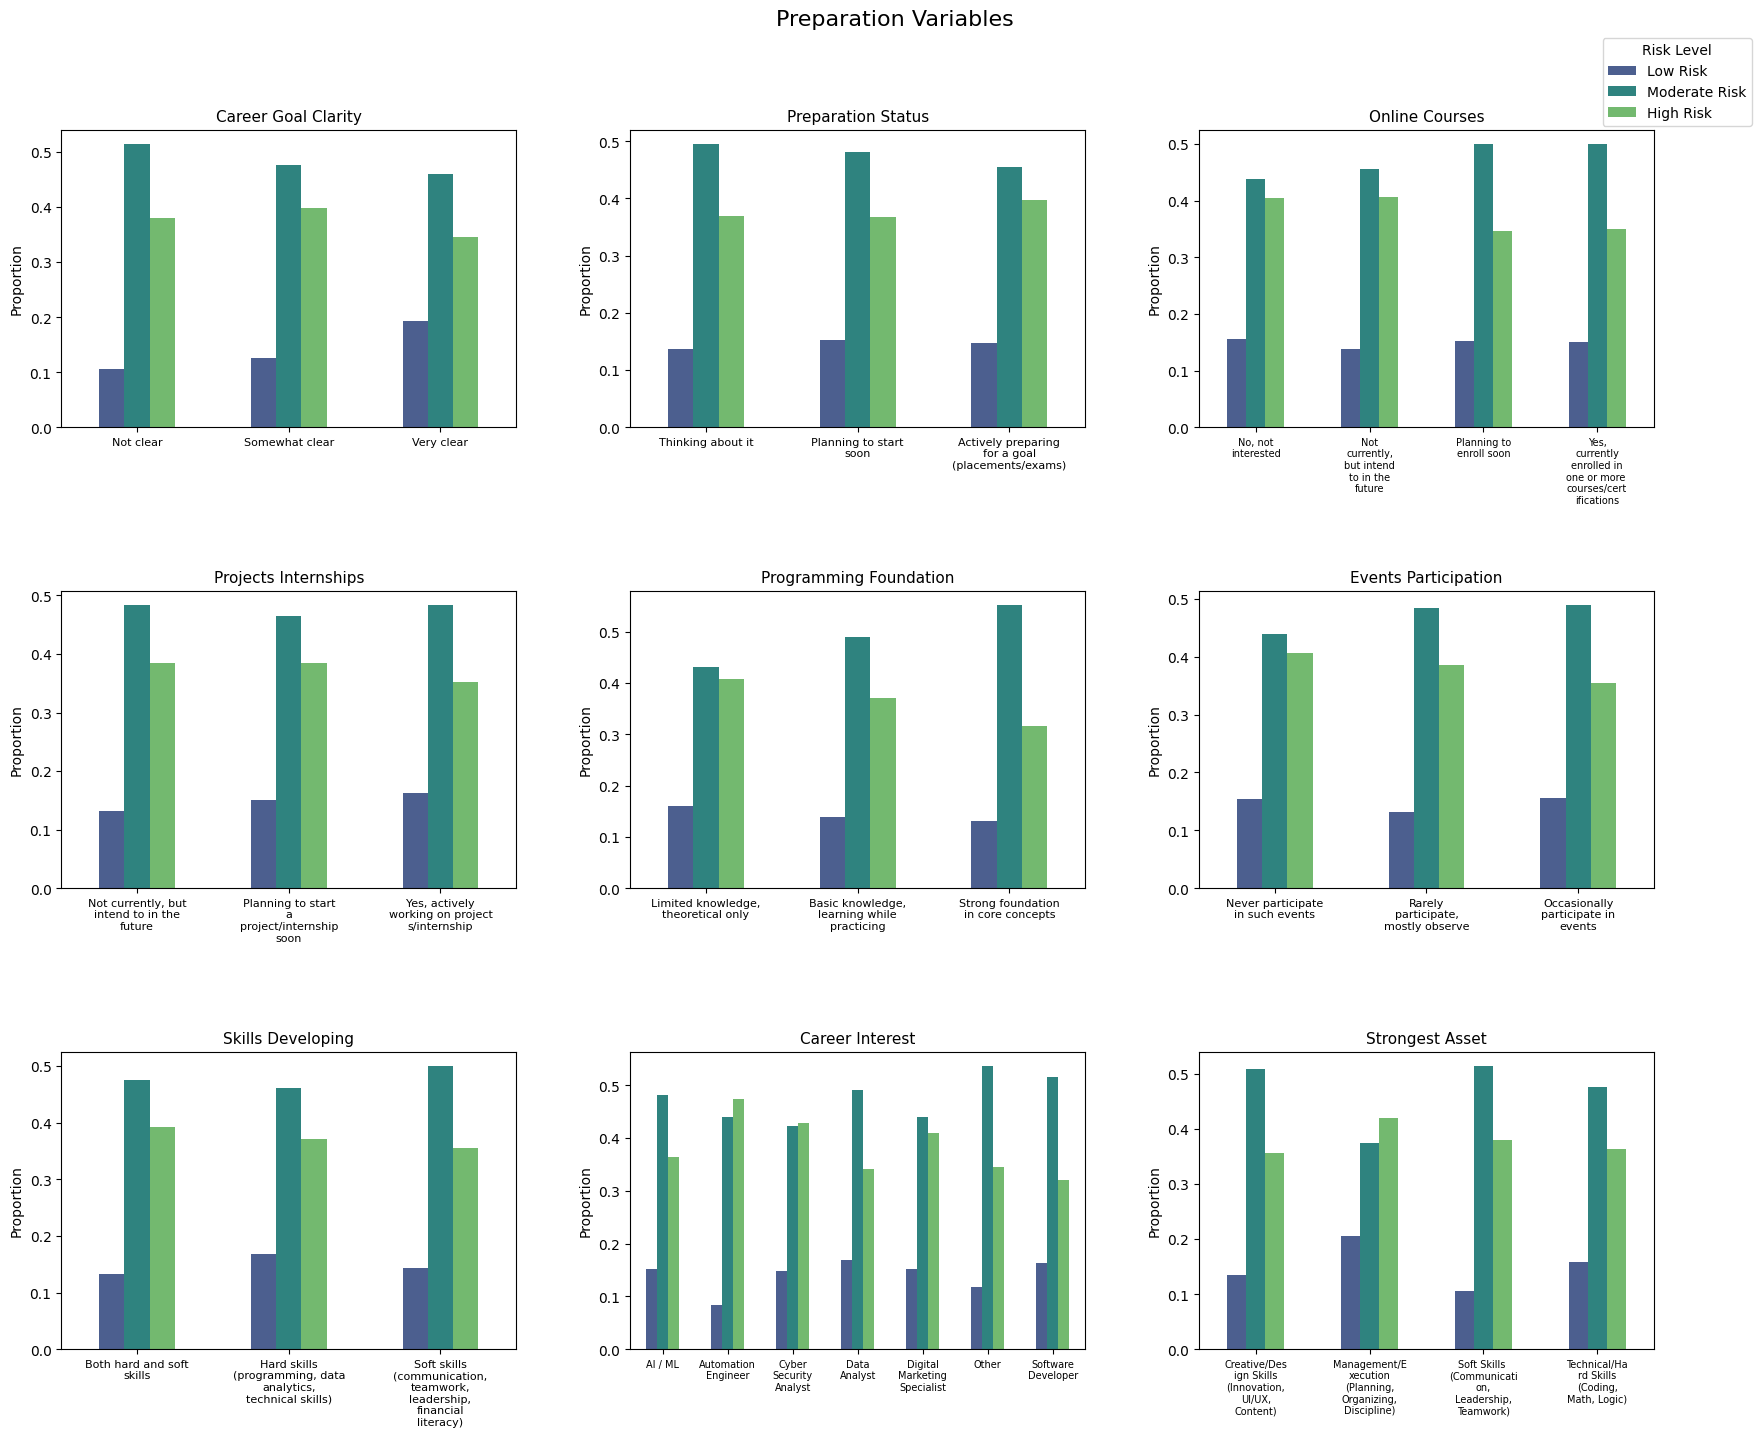

In [21]:
# Plot preparation and career development variables against risk level
plot_feature_group(
    data=df_model, 
    features=preparation_features, 
    target=target,
    risk_order=risk_order,
    risk_palette=risk_palette,
    category_orders=category_orders,
    rows=3,
    cols=3,
    title="Preparation Variables")

#### 4.4.1 Preparation Insights

The preparation variables show several useful but less uniform relationships with academic risk. Career goal clarity shows one of the clearer patterns, with low-risk proportions increasing as students report clearer career goals. High-risk proportions generally decrease as clarity improves, although the “somewhat clear” category is slightly higher than expected.

Preparation status, online courses, projects/internships, and events participation show weaker but still potentially useful patterns. In these variables, low-risk proportions change only slightly, while high-risk proportions generally decrease as students report more active preparation or involvement. This suggests that preparation behaviours may reduce the likelihood of high academic risk, although they do not always strongly separate low-risk students from moderate-risk students.

Programming foundation shows an interesting pattern. Students with stronger programming foundations have lower high-risk proportions, while moderate-risk proportions increase. However, the low-risk proportion is highest for students with limited theoretical knowledge, which suggests the relationship may be affected by other variables such as program of study, year level, or attendance.

Skills developing shows a similar mixed pattern, where high-risk proportions decrease across stronger skill-development categories, but low-risk and moderate-risk proportions fluctuate. This suggests the variable may contain useful information, but the relationship is not strictly linear.

Career interest and strongest asset are nominal variables, so no ordered trend should be inferred. However, both variables show noticeable differences in risk proportions across categories, suggesting that certain career interests or self-reported strengths may be associated with different academic risk profiles. These features may still be useful predictors if included as categorical variables in the model.

Overall, the preparation variables appear to provide some predictive information, particularly career goal clarity, programming foundation, and potentially career interest or strongest asset. However, many of the relationships are less consistent than the study behaviour variables, meaning these predictors may be more useful when combined with other variables rather than interpreted individually.

### 4.5 Student Background Variables

In addition to the study behaviour, lifestyle, and preparation variables, two background variables were examined: year level and program stream. Year level is treated as ordinal because students progress through academic stages, while program stream is treated as nominal because the categories represent different study areas rather than ordered levels.

In [22]:
# Student background variables to explore
background_features = ["year_class", "program_stream"]

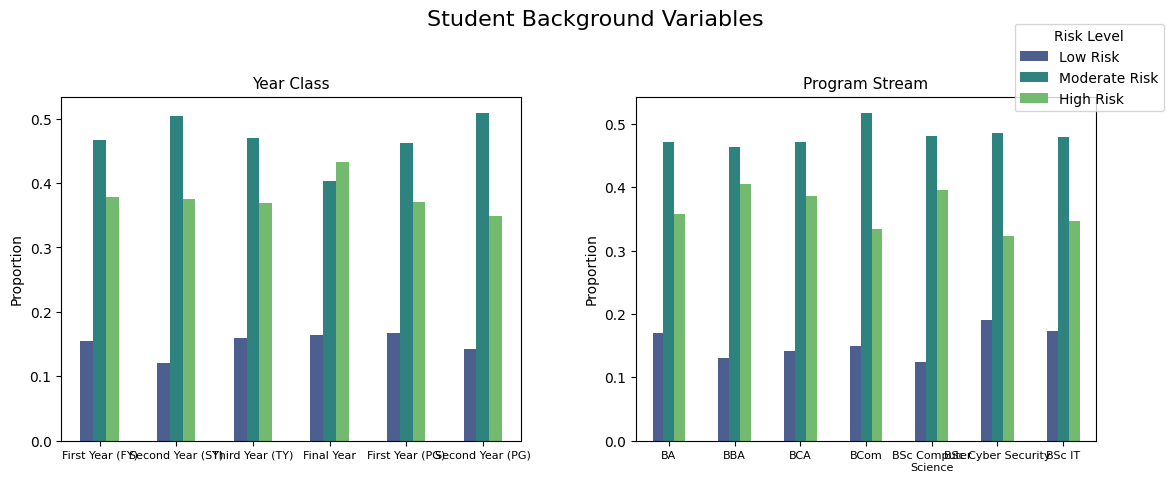

In [23]:
# Plot student background variables against risk level
plot_feature_group(
    data=df_model,
    features=background_features,
    target=target,
    risk_order=risk_order,
    risk_palette=risk_palette,
    category_orders=category_orders,
    rows=1,
    cols=2,
    title="Student Background Variables"
)

#### 4.5.1 Student Background Insights
Year level showed some variation in academic risk proportions across stages of study. Final-year students displayed the highest proportion of high-risk students and the lowest proportion of moderate-risk students, which may reflect increased academic pressure, workload, or career-related stress during the final stage of study. In contrast, second-year groups tended to show lower high-risk proportions and higher moderate-risk proportions. However, the differences between year levels were still smaller than those observed for several behavioural and lifestyle variables.

Program stream also displayed noticeable differences in academic risk proportions across categories. BCom students appeared to have the lowest proportion of high-risk students and the highest proportion of moderate-risk students, while programs such as BBA and BSc Computer Science showed relatively higher high-risk proportions. Cyber Security and IT programs showed slightly higher low-risk proportions compared to several other streams. Since program stream is a nominal variable, these differences should be interpreted as category-specific effects rather than ordinal trends.

Overall, both variables may still contribute useful background information to the predictive models, although their relationships with academic risk appear weaker and less consistent than several study behaviour and lifestyle predictors.

### 4.6 EDA Summary
The exploratory data analysis identified several variables that appear to have meaningful relationships with academic risk. Across the study behaviour variables, the clearest patterns were observed for study hours, tasks completed on time, academic satisfaction, and revision frequency. These variables generally showed decreasing proportions of high-risk students and increasing proportions of low or moderate-risk students as positive study behaviours increased. Academic satisfaction and task completion behaviour appeared to provide some of the strongest separation between risk groups.

Among the lifestyle variables, energy level and sleep hours showed the clearest relationships with academic risk. Higher reported energy levels were associated with increasing low-risk proportions and decreasing high-risk proportions, while greater sleep duration generally corresponded with lower high-risk proportions. Several other lifestyle variables, such as external resources and screen time outside study, showed weaker or less consistent relationships. Nominal variables such as main distractor and internal barrier displayed category-specific differences but no interpretable ordinal trend.

The preparation variables displayed more mixed relationships overall. Career goal clarity showed one of the clearest trends, with clearer career goals generally associated with lower academic risk. Programming foundation also showed an interesting pattern, where stronger foundations corresponded with lower high-risk proportions but not necessarily higher low-risk proportions. Career interest and strongest asset showed noticeable variation between categories, suggesting they may still provide useful predictive information when included as categorical variables.

Student background variables showed weaker but potentially useful relationships with academic risk. Year level displayed some variation, with final-year students showing a higher high-risk proportion, while program stream showed category-specific differences across academic risk levels. These variables may provide useful contextual information in the model, although they appear less predictive individually than the strongest study behaviour and lifestyle variables.

A recurring pattern across many variables was that reductions in high-risk proportions were often accompanied more strongly by increases in moderate-risk proportions rather than large increases in low-risk proportions. This suggests that positive behaviours and preparation habits may reduce severe academic risk without necessarily corresponding to consistently low academic risk outcomes.

Overall, the EDA suggests that variables related to consistency, engagement, satisfaction, energy level, and academic preparation are likely to provide the most useful predictive information for modelling academic risk. These findings were used to guide interpretation of the modelling results and to suggest a small number of theoretically meaningful interaction terms for further investigation.

## 5. Predictive Modelling

Following the exploratory data analysis, predictive modelling was conducted to investigate whether the constructed academic risk label could be predicted using behavioural, lifestyle, preparation, and background variables. Particular emphasis was placed on correctly identifying Moderate Risk and High Risk students, as failing to identify academically at-risk students may reduce opportunities for timely intervention and support.

The primary modelling objective was multiclass classification of the `performance_risk_level` target variable, which contains three categories: Low Risk, Moderate Risk, and High Risk. Variables directly involved in constructing the target label were excluded from the main modelling dataset to reduce target leakage and encourage the models to learn broader behavioural patterns rather than simply reconstructing the target formula.

An initial full main-effects model was first fitted using all remaining predictors. A reduced logistic regression model was then considered to determine whether similar predictive performance could be achieved with a smaller and more interpretable set of variables. A small number of interaction terms were also considered based on EDA findings and practical reasoning about how certain behaviours may combine to influence academic risk.

Finally, a random forest classifier was fitted as a more flexible machine learning model capable of capturing nonlinear relationships and interactions without requiring them to be specified manually. Model performance was evaluated using classification accuracy, confusion matrices, and class-level precision, recall, and F1-scores to assess how effectively each model distinguished between the three academic risk categories.

### 5.1 Train-Test Split and Preprocessing

Before fitting the predictive models, the dataset was divided into training and testing sets. The training set was used for model fitting, while the testing set was reserved for evaluating predictive performance on unseen data.

Since the dataset contains both ordinal and nominal categorical variables, preprocessing was required before modelling. Ordinal variables were encoded using their defined category orderings, while nominal variables were transformed using one-hot encoding. This preprocessing pipeline ensures that the models can appropriately interpret the categorical predictors.

In [24]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ordinal category orderings for OrdinalEncoder
ordinal_categories = [
    list(ordinal_mappings[col].keys())
    for col in ordinal_features
]

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop=None
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("nom", nominal_transformer, nominal_features)
    ],
    remainder="drop"
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

Training set shape: (960, 29)
Testing set shape: (240, 29)
Training target distribution:
performance_risk_level
Moderate Risk    0.477083
High Risk        0.376042
Low Risk         0.146875
Name: proportion, dtype: float64


### 5.2 Full Main-Effects Multinomial Logistic Regression

A multinomial logistic regression model using the full set of remaining predictors was first fitted as an interpretable baseline model. This model allows relationships between the predictors and academic risk categories to be examined while providing a benchmark for later model comparisons.

The model will then be evaluated using classification accuracy, confusion matrices, and per-class precision, recall, and F1-scores on the testing dataset.

In [25]:
# Create the logistic regression model pipeline
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit the model on the training data
log_reg_model.fit(X_train, y_train)

# Predict academic risk levels on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate model performance
print("Logistic Regression Model Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print()
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Model Performance
Accuracy: 0.5166666666666667

               precision    recall  f1-score   support

    High Risk       0.62      0.67      0.64        91
     Low Risk       0.30      0.57      0.39        35
Moderate Risk       0.58      0.38      0.46       114

     accuracy                           0.52       240
    macro avg       0.50      0.54      0.50       240
 weighted avg       0.55      0.52      0.52       240



c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The multinomial logistic regression model achieved moderate predictive performance, with an overall accuracy of approximately 51.7%. Performance varied across academic risk categories, with the model performing strongest for the High Risk class while showing weaker predictive ability for the Low Risk and Moderate Risk classes. This suggests that linear decision boundaries may not fully capture the underlying relationships within the dataset, motivating the exploration of more flexible classification models in subsequent analyses.

### 5.3 Reduced Logistic Regression Model

A reduced logistic regression model was then explored in order to investigate whether similar predictive performance could be achieved using a smaller subset of predictors. Predictor reduction was guided by patterns observed during the exploratory data analysis and practical interpretability considerations.

A small number of theoretically meaningful interaction terms were also considered to test whether combinations of study behaviour and lifestyle variables improved model performance.

In [39]:
# Reduced feature subset
reduced_features = [
    "year_class",
    "study_hours_daily",
    "academic_satisfaction",
    "tasks_on_time",
    "assignments_on_time",
    "revision_frequency",
    "energy_level",
    "sleep_hours",
    "career_goal_clarity"
]

# Create reduced dataset
X_reduced = df_model[reduced_features].copy()

In [40]:
# Create interaction terms
X_reduced["study_energy_interaction"] = (
    X_reduced["study_hours_daily"].astype(str) +
    "_" +
    X_reduced["energy_level"].astype(str)
)

X_reduced["tasks_satisfaction_interaction"] = (
    X_reduced["tasks_on_time"].astype(str) +
    "_" +
    X_reduced["academic_satisfaction"].astype(str)
)

In [41]:
# Reduced ordinal features
reduced_ordinal_features = [
    "year_class",
    "study_hours_daily",
    "academic_satisfaction",
    "tasks_on_time",
    "assignments_on_time",
    "revision_frequency",
    "sleep_hours",
    "career_goal_clarity"
]

# Reduced numeric features
reduced_numeric_features = [
    "energy_level"
]

# Interaction features
interaction_features = [
    "study_energy_interaction",
    "tasks_satisfaction_interaction"
]

In [42]:
# Ordinal category orderings for reduced model
reduced_ordinal_categories = [
    list(ordinal_mappings[col].keys())
    for col in reduced_ordinal_features
]

# Reduced ordinal transformer
reduced_ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=reduced_ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

In [43]:
# Reduced preprocessing pipeline
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, reduced_numeric_features),
        ("ord", reduced_ordinal_transformer, reduced_ordinal_features),
        ("int", OneHotEncoder(handle_unknown="ignore"), interaction_features)
    ],
    remainder="drop"
)

In [44]:
# Train-test split for reduced model
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
# Reduced logistic regression model
reduced_log_reg_model = Pipeline(steps=[
    ("preprocessor", reduced_preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit the model
reduced_log_reg_model.fit(X_train_red, y_train_red)

# Predict on the test set
y_pred_red = reduced_log_reg_model.predict(X_test_red)

# Evaluate model performance
print("Reduced Logistic Regression Model Performance")
print("Accuracy:", accuracy_score(y_test_red, y_pred_red))
print()
print(classification_report(y_test_red, y_pred_red))

Reduced Logistic Regression Model Performance
Accuracy: 0.44166666666666665

               precision    recall  f1-score   support

    High Risk       0.57      0.62      0.59        91
     Low Risk       0.29      0.66      0.40        35
Moderate Risk       0.44      0.24      0.31       114

     accuracy                           0.44       240
    macro avg       0.43      0.50      0.43       240
 weighted avg       0.46      0.44      0.43       240



c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The reduced logistic regression model achieved an overall accuracy of approximately 44.2%, which was lower than the full main-effects logistic regression model. Although the reduced model remained reasonably effective at identifying High Risk students, its weaker performance for the Moderate Risk class suggests that the removed predictors contained useful information for distinguishing between intermediate risk levels. This indicates that the simpler model improved interpretability but did so at the cost of predictive performance.

### 5.4 Random Forest Classifier

A random forest classifier was fitted as a more flexible machine learning model capable of capturing nonlinear relationships and complex interactions between predictors. Unlike logistic regression, the random forest does not require explicit specification of interaction terms and can automatically identify important variable splits during training.

The random forest model was evaluated using the same testing metrics as the logistic regression models to allow direct comparison of predictive performance.

In [46]:
# Create the random forest model pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Predict academic risk levels on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate model performance
print("Random Forest Model Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Model Performance
Accuracy: 0.5541666666666667

               precision    recall  f1-score   support

    High Risk       0.60      0.65      0.62        91
     Low Risk       0.35      0.17      0.23        35
Moderate Risk       0.54      0.60      0.57       114

     accuracy                           0.55       240
    macro avg       0.50      0.47      0.47       240
 weighted avg       0.54      0.55      0.54       240



The random forest classifier achieved the strongest predictive performance among the fitted models, with an overall accuracy of approximately 55.4%. The model particularly improved classification performance for the Moderate Risk category compared to the reduced logistic regression model, suggesting that nonlinear relationships and complex interactions between predictors may exist within the dataset. However, the improvement over the full logistic regression model remained relatively modest, indicating that the available behavioural and background variables still provide limited predictive separation once direct target-construction variables are removed.

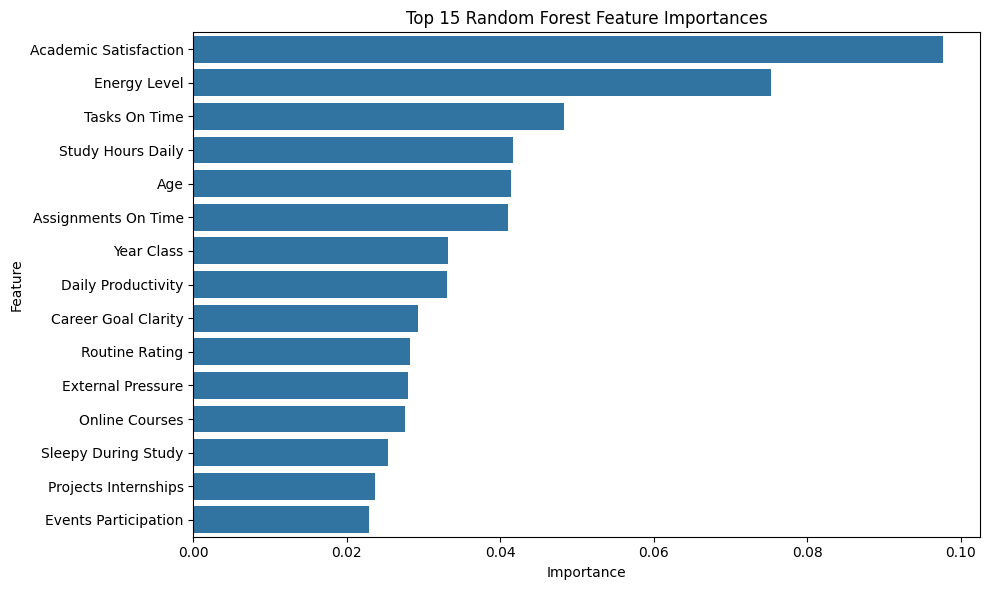

In [50]:
# Extract feature importances from the random forest model
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Clean feature names for plotting
feature_names = [
    name.replace("num__", "")
        .replace("ord__", "")
        .replace("nom__", "")
        .replace("_", " ")
        .title()
    for name in feature_names
]

importances = rf_model.named_steps["model"].feature_importances_

# Create dataframe of feature importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

# Plot feature importances
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The random forest feature importance results were broadly consistent with patterns identified during the exploratory data analysis. Academic satisfaction appeared as the most influential predictor by a noticeable margin, followed by energy level, tasks completed on time, and study hours daily. These variables were also among the clearest predictors during the EDA, where stronger study habits, higher satisfaction, and greater energy levels were generally associated with lower academic risk. Assignment punctuality, year class, and career goal clarity also showed moderate importance, suggesting that both behavioural and contextual factors contribute to academic risk classification. Overall, the feature importance results reinforce the idea that academic risk is influenced by a combination of study consistency, personal wellbeing, and academic engagement rather than any single variable alone.

### 5.5 Model Comparison

Although the random forest classifier achieved the highest overall accuracy, the full main-effects logistic regression model was considered the most useful model overall because it provided stronger performance for the Moderate Risk and High Risk categories. These categories were prioritised because failing to identify students at moderate or high academic risk may reduce opportunities for timely intervention and academic support. Therefore, class-level recall and F1-score were considered more informative than overall accuracy alone.

The reduced logistic regression model produced lower performance than the full model, suggesting that the excluded predictors still contained collectively useful information. Overall, the results suggest that the remaining behavioural, lifestyle, preparation, and background variables provide some predictive signal, but only limited separation once direct target-construction variables are removed.

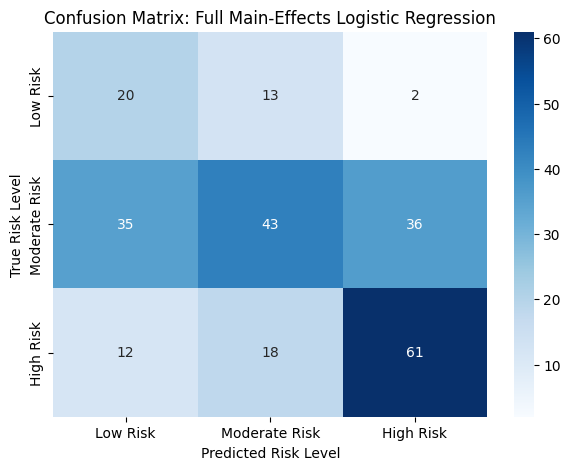

In [48]:
# Confusion matrix for the selected model
risk_order = ["Low Risk", "Moderate Risk", "High Risk"]

cm_full = confusion_matrix(y_test, y_pred_log_reg, labels=risk_order)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_full,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=risk_order,
    yticklabels=risk_order
)

plt.xlabel("Predicted Risk Level")
plt.ylabel("True Risk Level")
plt.title("Confusion Matrix: Full Main-Effects Logistic Regression")
plt.show()

### 5.6 Key Modelling Insights and Limitations

Overall, the modelling results suggest that the constructed academic risk label was difficult to predict strongly once direct target-construction variables were removed. Although the stronger models achieved some improvement over a naive majority-class baseline, the performance gains were relatively modest, indicating that the remaining behavioural, lifestyle, preparation, and background variables only partially explain variation in academic risk.

A key limitation is that the response variable was not a directly observed academic outcome, but a derived risk label constructed from multiple underlying academic and behavioural components. Variables such as CGPA category, attendance percentage, stress level, and academic consistency were excluded from the main modelling dataset to reduce target leakage. As a result, the models were required to predict the constructed risk label indirectly using broader survey variables, which likely reduced predictive performance.

This suggests that academic risk is influenced by a complex combination of factors rather than any single variable or small group of variables. The moderate model performance may therefore reflect the difficulty of classifying students into risk categories using indirect behavioural and background predictors alone. Consequently, the models should be interpreted as exploratory tools for identifying broad patterns associated with academic risk rather than as highly reliable predictive systems.

## 6. Conclusion
This analysis explored the use of multinomial logistic regression and random forest classification models to predict student academic risk levels using behavioural, lifestyle, preparation, and background variables. The exploratory data analysis identified several variables with meaningful relationships to academic risk, particularly academic satisfaction, study hours, task completion behaviour, energy level, and career goal clarity.

The full main-effects logistic regression model provided the strongest overall balance between predictive performance and practical usefulness, particularly in identifying moderate-risk and high-risk students, which were considered the most important categories for this analysis. The reduced logistic regression model achieved slightly lower performance, suggesting that academic risk depends on a broader combination of interacting factors rather than a very small subset of predictors. The random forest classifier produced only a modest improvement in overall accuracy despite its increased flexibility and ability to capture nonlinear relationships.

A key limitation of the analysis is that the response variable was itself constructed using several underlying academic and behavioural measures. Although direct target-construction variables were excluded to reduce leakage, some remaining predictors may still be conceptually related to the target definition. This likely contributed to the difficulty of achieving strong generalisable predictive performance while also limiting direct causal interpretation of the results.

Overall, the modelling results suggest that academic risk is a complex outcome influenced by multiple interconnected behavioural and lifestyle factors. While the models demonstrated some ability to distinguish between risk groups, the relatively modest predictive performance indicates that student academic risk may be difficult to classify accurately using survey-based variables alone.